In [1]:
%load_ext autoreload
%autoreload 2

In [39]:
from collections import defaultdict
import functools
import operator
import pprint

import hydra
from omegaconf import OmegaConf
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=4)#, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import polars as pl
import duckdb

from conf import conf
from rna_vel_pred import datasets, plots, utils

In [5]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [6]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

### Training configs

##### Trained on three, save Pancraes

Configs using the optimal neighbor count and sparsification step for the three datasets trained on.

In [155]:
dataset_rows = duckdb.sql("""
select
    id as Dataset
from datasets_for_training_on_three_each_optimal
""")
training_conf_rows = duckdb.sql("""
select
    alt_id, id as Conf
from conf_trained_on_three_each_optimal
""")
training_conf_rows.show(max_width=125)
assert len(training_conf_rows) == 1
assert len(dataset_rows) == 4

┌──────────┬───────┐
│  alt_id  │ Conf  │
│ varchar  │ int64 │
├──────────┼───────┤
│ 0jgmar48 │  1425 │
└──────────┴───────┘



Configs using the average optimal neighbor count and sparsity over the three datasets trained on for each dataset.

In [178]:
dataset_rows = duckdb.sql("""
select
    id as Dataset
from datasets_for_training_on_three
""")
training_conf_rows = duckdb.sql("""
select
    alt_id, id as Conf
from conf_trained_on_three
""")
training_conf_rows.show(max_width=125)
assert len(training_conf_rows) == 1
assert len(dataset_rows) == 4

┌──────────┬───────┐
│  alt_id  │ Conf  │
│ varchar  │ int64 │
├──────────┼───────┤
│ 5j9qei7s │  1440 │
└──────────┴───────┘



##### Trained on four for final model

Configs using the optimal neighbor count and sparsification step for the three datasets trained on.
Pancreas uses the average optimal neighbor count and sparsity over the other three datasets.

In [154]:
dataset_rows = duckdb.sql("""
select
    id as Dataset
from datasets_for_training_on_three_each_optimal
""")
training_conf_rows = duckdb.sql("""
select
    alt_id, id as Conf
from conf_trained_on_four_each_optimal
""")
training_conf_rows.show(max_width=125)
assert len(training_conf_rows) == 1
assert len(dataset_rows) == 4

┌──────────┬───────┐
│  alt_id  │ Conf  │
│ varchar  │ int64 │
├──────────┼───────┤
│ iyrh96kd │  1434 │
└──────────┴───────┘



Configs using the average optimal neighbor count and sparsity over the three datasets trained on for each dataset.
Pancreas uses the average optimal neighbor count and sparsity over the other three datasets.

In [153]:
dataset_rows = duckdb.sql("""
select
    id as Dataset
from datasets_for_training_on_four
""")
training_conf_rows = duckdb.sql("""
select
    alt_id, id as Conf
from conf_trained_on_four
""")
training_conf_rows.show(max_width=125)
assert len(training_conf_rows) == 1
assert len(dataset_rows) == 4

┌──────────┬───────┐
│  alt_id  │ Conf  │
│ varchar  │ int64 │
├──────────┼───────┤
│ gr7os295 │  1441 │
└──────────┴───────┘



### General

In [179]:
rows = duckdb.sql("""
select
    *,
    H5adUMap.dataset as dataset_name,
from Conf
join Trained on Conf.Model = Trained.id
join Conf__Dataset on Conf.id = Conf__Dataset.Conf
join Dataset on Dataset.id = Conf__Dataset.Dataset
join H5adUMap on Dataset.id = H5adUMap.id
where true
and (Trained.Conf, Dataset.id) in (select Conf, Dataset from training_conf_rows cross join dataset_rows)
""")
rows.show(max_width=125)

┌──────────┬────────────┬───────┬─────────┬───┬────────────────────┬────────────────┬───────┬───────────────┐
│  alt_id  │  rng_seed  │  fit  │ predict │ … │ processed_filename │ umap_dimension │  id   │ dataset_name  │
│ varchar  │   int64    │ int64 │  int64  │   │      varchar       │     int64      │ int64 │    varchar    │
├──────────┼────────────┼───────┼─────────┼───┼────────────────────┼────────────────┼───────┼───────────────┤
│ av5a65j9 │ 2376999025 │     0 │       1 │ … │ ul00hu6t           │              2 │  1408 │ DENTATE_GYRUS │
│ dn2s4i2x │ 2376999025 │     0 │       1 │ … │ y2hhr6s7           │              2 │  1409 │ BONEMARROW    │
│ zfryre2w │ 2376999025 │     0 │       1 │ … │ hhxhv0m8           │              2 │  1410 │ FOREBRAIN     │
│ qxqwb8tv │ 2376999025 │     0 │       1 │ … │ dqexvo07           │              2 │  1415 │ PANCREAS      │
├──────────┴────────────┴───────┴─────────┴───┴────────────────────┴────────────────┴───────┴───────────────┤
│ 4 rows  

In [180]:
cfgs = session.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([
    alt_id for (alt_id,) in duckdb.sql("select alt_id from rows").fetchall()
])))
cfgs = {c.alt_id: c for (c,) in cfgs}
cfgs = {k: {'cfg': cfgs[k]} for k in cfgs}

In [181]:
alt_id_and_umap_dimension = duckdb.sql("""
select distinct
    alt_id, umap_dimension
from rows
""")
alt_id_and_umap_dimension
assert (
    len(duckdb.sql("select distinct alt_id from alt_id_and_umap_dimension"))
    ==
    len(duckdb.sql("select distinct alt_id from rows"))
)

In [182]:
cosine_distance_selects = {
    alt_id: 0.5 * functools.reduce(operator.add, [
        (pl.col(f'v{d}') - pl.col(f'v{d}_pred')).pow(2)
        for d in range(1, umap_dimension + 1)
    ])
    for alt_id, umap_dimension in duckdb.sql("select * from alt_id_and_umap_dimension").fetchall()
}
for k, v in cosine_distance_selects.items():
    print(f'{k}: {v}')

av5a65j9: [(dyn float: 0.5) * ([([(col("v1")) - (col("v1_pred"))].pow([dyn int: 2])) + ([(col("v2")) - (col("v2_pred"))].pow([dyn int: 2]))])]
zfryre2w: [(dyn float: 0.5) * ([([(col("v1")) - (col("v1_pred"))].pow([dyn int: 2])) + ([(col("v2")) - (col("v2_pred"))].pow([dyn int: 2]))])]
dn2s4i2x: [(dyn float: 0.5) * ([([(col("v1")) - (col("v1_pred"))].pow([dyn int: 2])) + ([(col("v2")) - (col("v2_pred"))].pow([dyn int: 2]))])]
qxqwb8tv: [(dyn float: 0.5) * ([([(col("v1")) - (col("v1_pred"))].pow([dyn int: 2])) + ([(col("v2")) - (col("v2_pred"))].pow([dyn int: 2]))])]


In [183]:
predictions = [
    (
        pl.scan_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)
        .with_columns(
            alt_id=pl.lit(v['cfg'].alt_id),
            cosine_distance=cosine_distance_selects[v['cfg'].alt_id],
        )
    )
    for v in cfgs.values()
]
predictions = pl.concat(predictions)
predictions.head().collect()

measurement_id,split,t,x1,x2,v1,v2,v1_pred,v2_pred,alt_id,cosine_distance
i64,str,f64,f64,f64,f64,f64,f64,f64,str,f64
744,"""train""",0.570629,6.979176,16.931364,0.334815,-0.942284,-0.373689,0.927554,"""av5a65j9""",1.999136
1147,"""train""",0.979581,4.698637,17.10367,-0.38685,-0.922143,-0.285818,0.958284,"""av5a65j9""",1.773106
1912,"""train""",0.560844,5.825074,-6.728027,-0.434286,-0.900775,0.084422,-0.99643,"""av5a65j9""",0.139104
2362,"""train""",0.987911,4.230345,15.193677,-0.547614,-0.836731,-0.373746,0.927531,"""av5a65j9""",1.571425
1397,"""train""",0.050852,5.919745,6.167345,-0.568749,0.822511,0.311437,0.950267,"""av5a65j9""",0.395525


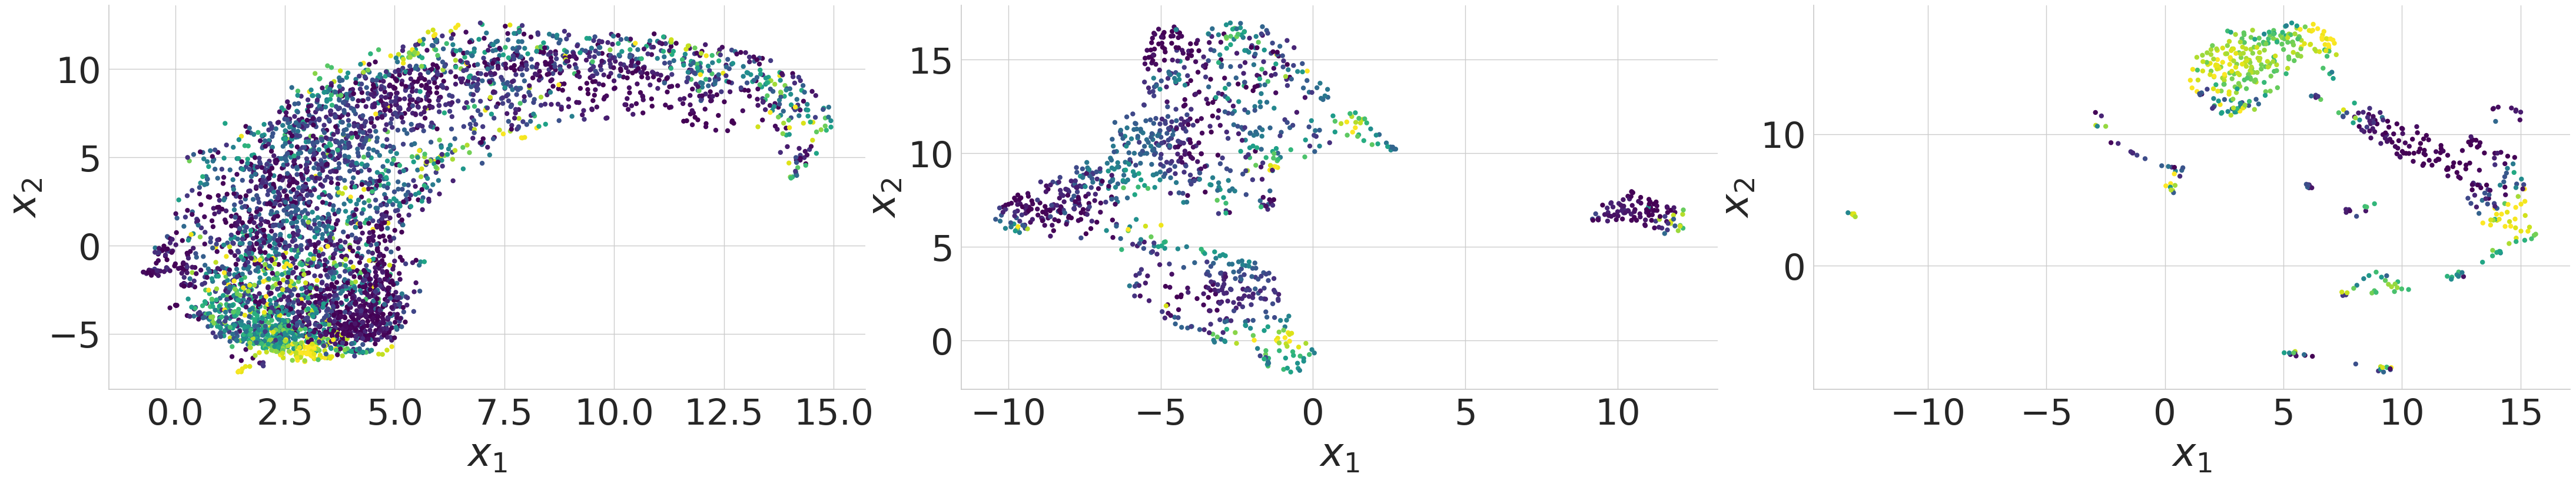

In [187]:
to_plot = duckdb.sql("""
select
    predictions.*,
    rows.dataset_name,
from predictions
join rows on predictions.alt_id = rows.alt_id
where true
and dataset_name != 'PANCREAS'
and split = 'val'
--and split != 'test'
""")
plot_heatmap = (
    sns.relplot(
        kind='scatter',
        data=to_plot.pl(),
        col='dataset_name',
        hue='cosine_distance',
        hue_norm=(0, 2),
        palette='viridis',
        x='x1', y='x2',
        height=10,
        aspect=1.5,
        # s=64,
        edgecolor='none',
        facet_kws=dict(
            sharex=False,
            sharey=False,
        ),
        legend=False,
    )
    .set_titles('')
)
for (row, col, hue), data in plot_heatmap.facet_data():
    ax = plot_heatmap.axes[row][col]
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    if False:
        x1, x2 = data['x1'], data['x2']
        v1, v2 = data['v1_pred'], data['v2_pred']
        color = None
    elif False:
        x1, x2 = data['x1'], data['x2']
        x1 = pd.concat([x1] * 2, ignore_index=True)
        x2 = pd.concat([x2] * 2, ignore_index=True)
        v1 = data[['v1', 'v1_pred']].melt(var_name='is_pred', value_name='v')
        v1, is_pred = v1['v'], (v1['is_pred'] == 'v1_pred').astype(float)
        v2 = data[['v2', 'v2_pred']].melt(var_name='is_pred', value_name='v')['v']
        cmap = matplotlib.colors.LinearSegmentedColormap.from_list('vel_pred', ['tab:orange', 'deepskyblue'])
        color = cmap(is_pred)

In [51]:
plots.save_all_subfigures(plot_heatmap, 'Predict', renaming=label_to_alt_id, metadata_dataframe=pl.DataFrame(to_plot).select('alt_id', 'Model').unique())

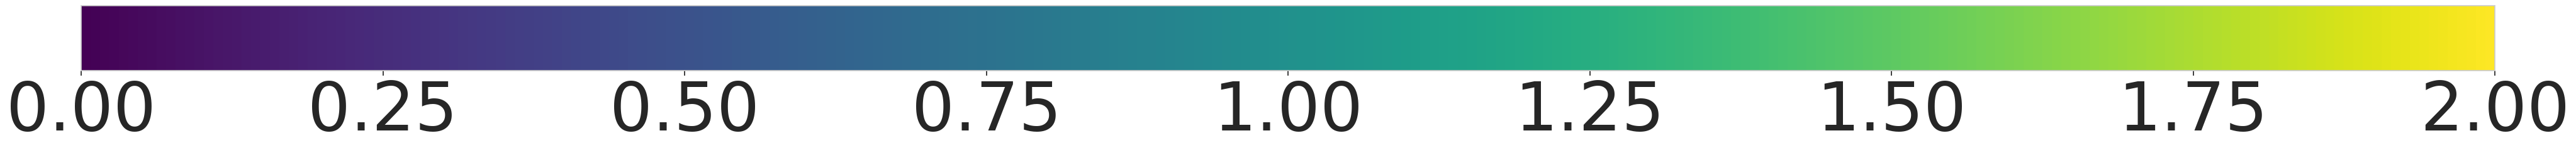

In [38]:
scale = 1.5
fig, (ax, ax_cbar) = plt.subplots(2, 1, height_ratios=[45, 1], figsize=(33*scale, 45*scale))
out = ax.imshow(np.linspace(0, 2, 10)[None], cmap='viridis')
fig.colorbar(out, cax=ax_cbar, orientation='horizontal')
ax.remove()
fig.savefig('Predict.colorbar.pdf', format='pdf', bbox_inches='tight', pad_inches=.03)

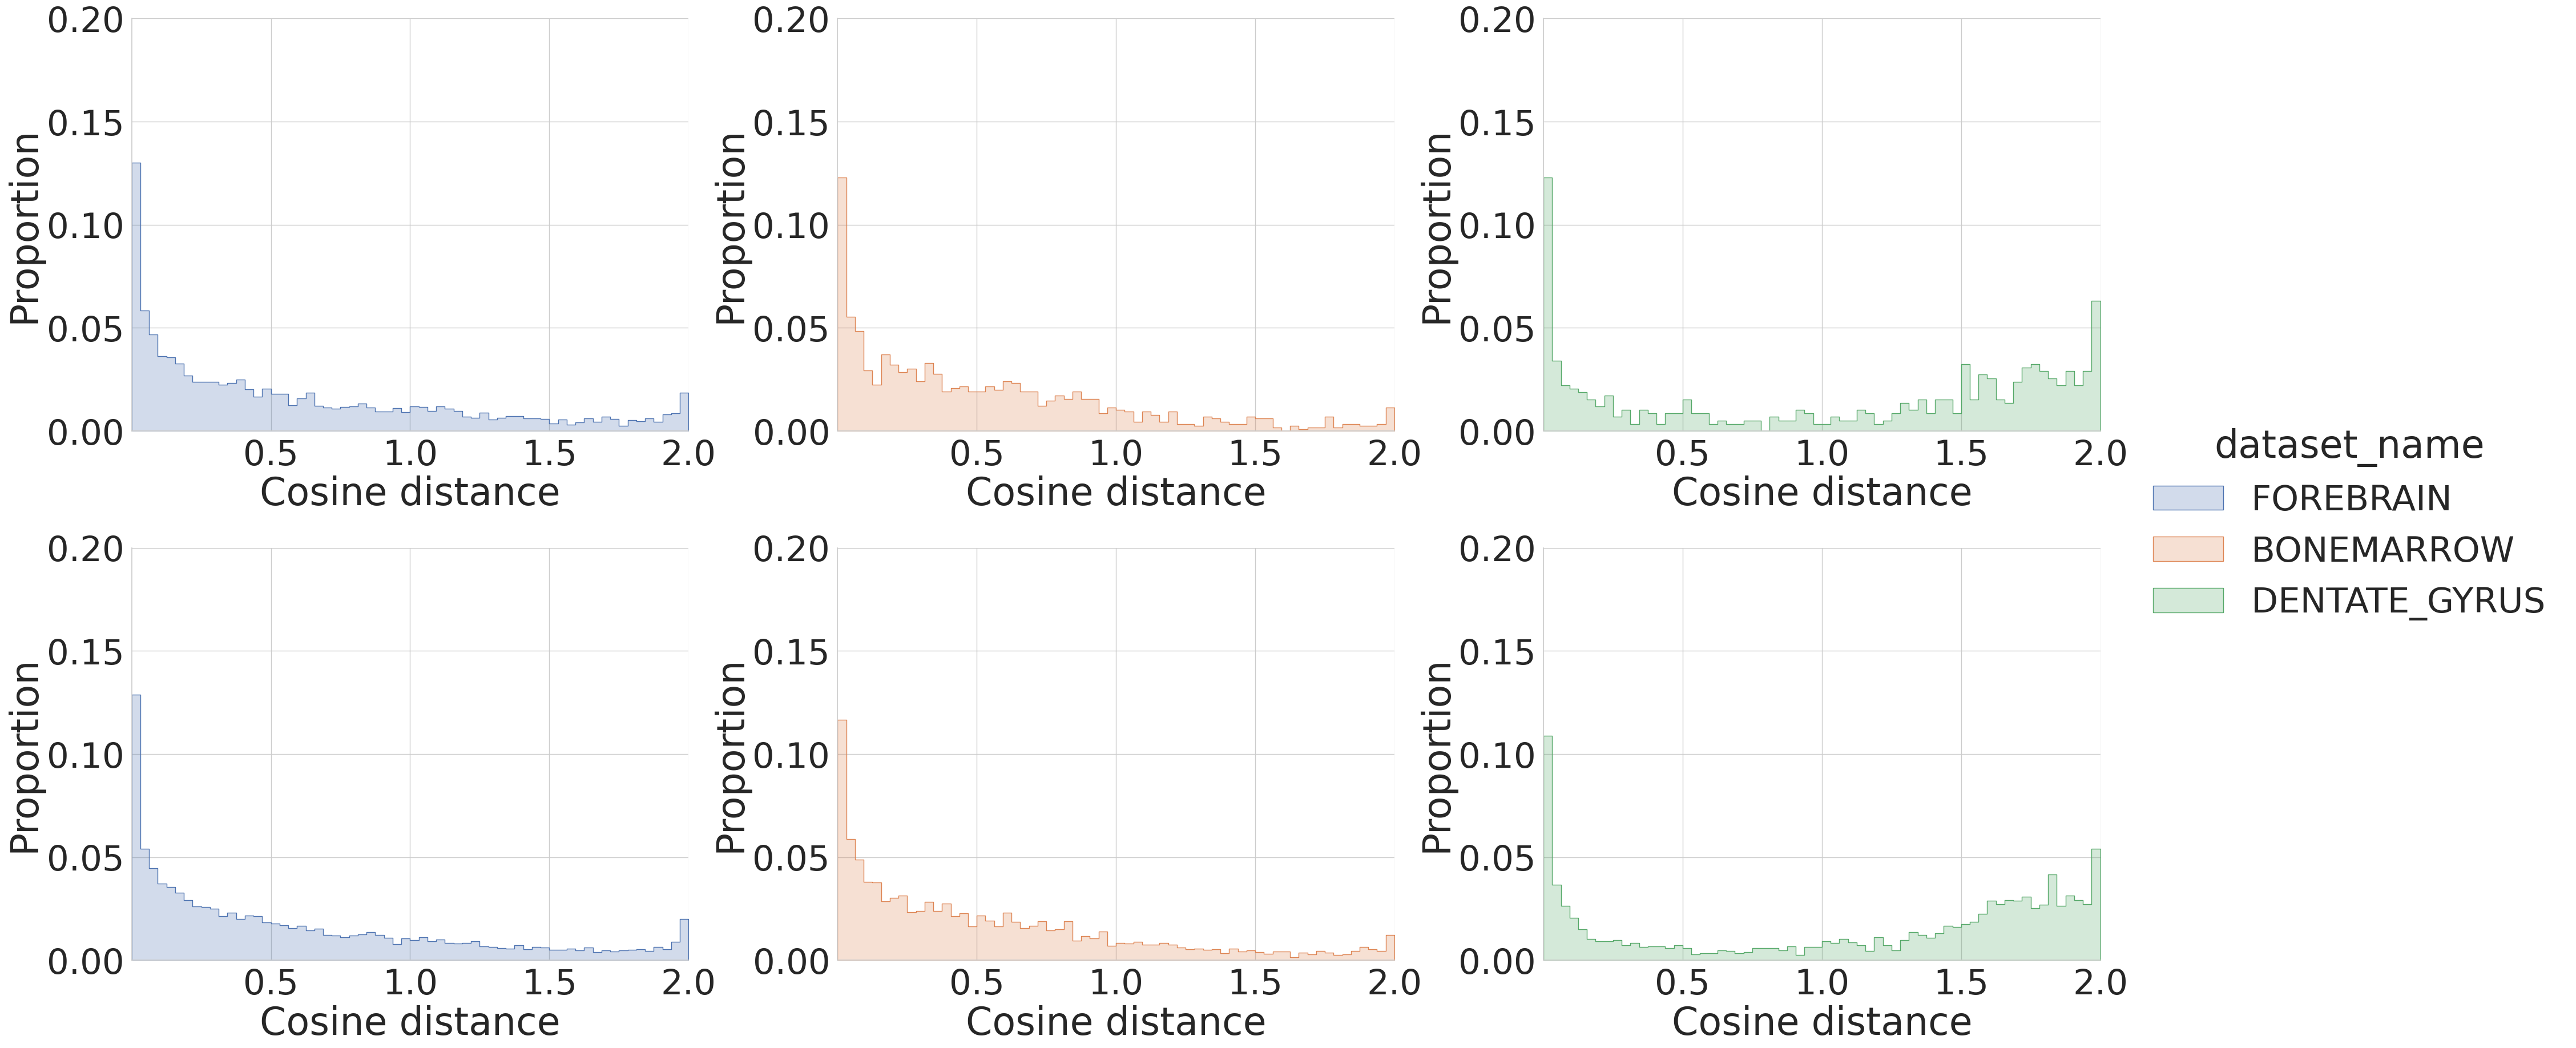

In [185]:
plot_histogram = (
    sns.displot(
        data=duckdb.sql("""
            select
                *
            from to_plot
            where true
            and dataset_name != 'PANCREAS'
            and split != 'test'
        """).pl(),
        element='step',
        stat='proportion',
        col='dataset_name',
        row='split',
        x='cosine_distance',
        hue='dataset_name',
        common_norm=False,
        height=10,
        aspect=1.3,
        bins=64,
        # bins=32,
        # bins=16,
        # legend=False,
        facet_kws=dict(
            sharex=False,
            sharey=False,
        )
    )
    .set(
        ylim=(0,.2),
        xlim=(0,2),
        xticks=[.5, 1., 1.5, 2.],
    )
    .set_titles('')
)
for (row, col, hue), data in plot_histogram.facet_data():
    ax = plot_histogram.axes[row][col]
    ax.set_xlabel('Cosine distance')
    ax.set_ylabel('Proportion')

In [10]:
plots.save_all_subfigures(plot_histogram, 'Histogram', renaming=label_to_alt_id, metadata_dataframe=pl.DataFrame(to_plot))